# Modelado predictivo de NO₂ con información histórica

Este notebook desarrolla y evalúa un modelo XGBoost para la predicción diaria de la concentración de NO₂ incorporando información histórica del propio contaminante mediante variables temporales retardadas (*lags*).

El objetivo es cuantificar la aportación predictiva de conocer el estado reciente del NO₂ respecto al modelo desarrollado sin información histórica.

Para garantizar una comparación objetiva entre ambos enfoques se mantienen:

- las mismas variables meteorológicas;
- las mismas variables de calendario;
- la misma representación espacial de las estaciones;
- la misma división temporal;
- el mismo procedimiento de optimización y evaluación.

La única diferencia fundamental será la incorporación de variables históricas de NO₂.

La metodología temporal utilizada es:

- **2020-2022:** entrenamiento y optimización interna.
- **2023:** validación externa.
- **2024:** test final.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# CARGA DEL DATASET DE MODELADO
# ============================================================

ROOT = Path.cwd()

while not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "modeling" / "dataset_no2.parquet"

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado correctamente")
print("Shape:", df.shape)

display(df.head())

Dataset cargado correctamente
Shape: (40040, 24)


,fecha,estacion,contaminante_t,es_laborable_madrid_ciudad,direccion_racha_max,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,...,temp_min,viento_racha,viento_velocidad,mes,mes_sin,mes_cos,no2_lag_1,no2_lag_2,no2_lag_3,no2_lag_7
0,2020-01-08,8,99.791667,True,90.0,72.0,47.0,27.0,8.8,0.0,...,1.8,3.3,0.3,1,0.5,0.866025,85.130435,60.083333,51.291667,65.666667
1,2020-01-09,8,77.958333,True,300.0,75.0,59.0,49.0,8.6,0.0,...,4.0,9.4,1.1,1,0.5,0.866025,99.791667,85.130435,60.083333,68.083333
2,2020-01-10,8,54.500000,True,40.0,73.0,50.0,37.0,8.9,0.0,...,4.2,9.7,3.3,1,0.5,0.866025,77.958333,99.791667,85.130435,73.458333
3,2020-01-11,8,56.625000,False,50.0,69.0,52.0,38.0,9.2,0.0,...,2.0,6.1,1.4,1,0.5,0.866025,54.500000,77.958333,99.791667,42.347826
4,2020-01-12,8,70.375000,False,170.0,76.0,69.0,56.0,9.1,0.0,...,-0.7,3.1,1.1,1,0.5,0.866025,56.625000,54.500000,77.958333,51.291667


In [2]:
# ============================================================
# CARGA DE METADATA DE ESTACIONES
# ============================================================

ESTACIONES_PATH = (
    ROOT
    / "data"
    / "enriched"
    / "dims"
    / "dim_estaciones_aire.parquet"
)

estaciones_aire = pd.read_parquet(
    ESTACIONES_PATH
)

metadata_modelo = estaciones_aire[
    [
        "ESTACION",
        "LATITUD_G",
        "LONGITUD_G",
        "ALTITUD",
        "TIPO_ESTACION"
    ]
].copy()

metadata_modelo = metadata_modelo.rename(
    columns={"ESTACION": "estacion"}
)

filas_antes = len(df)

df = df.merge(
    metadata_modelo,
    on="estacion",
    how="left",
    validate="many_to_one"
)

assert len(df) == filas_antes

print("✓ Metadata de estaciones incorporada correctamente.")

✓ Metadata de estaciones incorporada correctamente.


In [3]:
# ============================================================
# ONE-HOT ENCODING DEL TIPO DE ESTACIÓN
# ============================================================

df_modelo = pd.get_dummies(
    df,
    columns=["TIPO_ESTACION"],
    prefix="tipo_estacion",
    dtype=int
)

columnas_tipo_estacion = [
    col
    for col in df_modelo.columns
    if col.startswith("tipo_estacion_")
]

print(columnas_tipo_estacion)

['tipo_estacion_FONDO', 'tipo_estacion_TRAFICO']


In [4]:
# ============================================================
# FEATURES Y TARGET
# ============================================================

TARGET = "contaminante_t"

features_meteo = [
    "direccion_racha_max",
    "humedad_media",
    "precipitacion",
    "presion_max",
    "presion_min",
    "temp_max",
    "temp_media",
    "temp_min",
    "viento_racha",
    "viento_velocidad",
]

features_calendario = [
    "es_laborable_madrid_ciudad",
    "mes_sin",
    "mes_cos",
]

features_espaciales = [
    "LATITUD_G",
    "LONGITUD_G",
    "ALTITUD",
]

features_lags = [
    "no2_lag_1",
    "no2_lag_2",
    "no2_lag_3",
    "no2_lag_7",
]

FEATURES = (
    features_meteo
    + features_calendario
    + features_espaciales
    + columnas_tipo_estacion
    + features_lags
)

X = df_modelo[FEATURES].copy()
y = df_modelo[TARGET].copy()

print("Número de features:", len(FEATURES))
print("Nulos X:", X.isna().sum().sum())
print("Nulos y:", y.isna().sum())

Número de features: 22
Nulos X: 0
Nulos y: 0


In [5]:
assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0

## División temporal del dataset

Al tratarse de un problema de predicción temporal, el dataset se divide respetando el orden cronológico de las observaciones, evitando realizar una partición aleatoria que pudiera introducir información futura durante el entrenamiento.

Se establecen tres conjuntos independientes:

- **Entrenamiento (2020-2022):** utilizado para entrenar los modelos.
- **Validación (2023):** utilizado para comparar configuraciones, optimizar hiperparámetros y tomar decisiones sobre la selección de variables.
- **Test (2024):** reservado para la evaluación final del modelo seleccionado.

Esta división permite simular un escenario más cercano al uso real del modelo, en el que se utilizan observaciones históricas para realizar predicciones sobre periodos futuros.

Además, mantener 2024 como conjunto de test independiente permite obtener una estimación de la capacidad de generalización temporal del modelo sobre datos no utilizados durante su desarrollo.

In [7]:
# ============================================================
# SPLIT TEMPORAL: TRAIN / VALIDATION / TEST
# ============================================================

# Aseguramos formato datetime
df_modelo["fecha"] = pd.to_datetime(df_modelo["fecha"])

# ------------------------------------------------------------
# Máscaras temporales
# ------------------------------------------------------------

# Train: 2020-2022
train_mask = (
    df_modelo["fecha"] < "2023-01-01"
)

# Validation: 2023
val_mask = (
    (df_modelo["fecha"] >= "2023-01-01")
    & (df_modelo["fecha"] < "2024-01-01")
)

# Test: 2024
test_mask = (
    df_modelo["fecha"] >= "2024-01-01"
)

# ------------------------------------------------------------
# Separación X / y
# ------------------------------------------------------------

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[val_mask].copy()
y_val = y.loc[val_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

# ------------------------------------------------------------
# Comprobación de periodos
# ------------------------------------------------------------

print("TRAIN")
print(
    df_modelo.loc[train_mask, "fecha"].min(),
    "→",
    df_modelo.loc[train_mask, "fecha"].max()
)
print("Observaciones:", len(X_train))

print("\nVALIDATION")
print(
    df_modelo.loc[val_mask, "fecha"].min(),
    "→",
    df_modelo.loc[val_mask, "fecha"].max()
)
print("Observaciones:", len(X_val))

print("\nTEST")
print(
    df_modelo.loc[test_mask, "fecha"].min(),
    "→",
    df_modelo.loc[test_mask, "fecha"].max()
)
print("Observaciones:", len(X_test))

print(
    "\nTotal:",
    len(X_train) + len(X_val) + len(X_test)
)

TRAIN
2020-01-08 00:00:00 → 2022-12-31 00:00:00
Observaciones: 23958

VALIDATION
2023-01-01 00:00:00 → 2023-12-31 00:00:00
Observaciones: 8030

TEST
2024-01-01 00:00:00 → 2024-12-31 00:00:00
Observaciones: 8052

Total: 40040


In [8]:
# ============================================================
# COMPROBACIÓN DEL SPLIT
# ============================================================

assert len(X_train) + len(X_val) + len(X_test) == len(df)

assert df.loc[train_mask, "fecha"].max() < df.loc[val_mask, "fecha"].min()
assert df.loc[val_mask, "fecha"].max() < df.loc[test_mask, "fecha"].min()

print("Split temporal correcto.")

Split temporal correcto.


## Modelo baseline

Como referencia se utiliza un modelo de **persistencia temporal**, que supone que la concentración de NO₂ del día siguiente será igual a la observada el día anterior.

Por tanto:

$$
\widehat{NO}_{2,t} = NO_{2,t-1}
$$

Este baseline permite determinar si el modelo desarrollado aporta capacidad predictiva adicional respecto a una estrategia temporal sencilla.

Durante la fase de desarrollo, la comparación con el baseline se realiza sobre el conjunto de validación de 2023.

In [9]:
# ============================================================
# BASELINE: PERSISTENCIA (NO2 DEL DÍA ANTERIOR)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicción baseline
y_pred_baseline = X_test["no2_lag_1"]

# Métricas
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print("BASELINE - Persistencia (lag 1)")
print("--------------------------------")
print(f"MAE:  {mae_baseline:.3f}")
print(f"RMSE: {rmse_baseline:.3f}")
print(f"R²:   {r2_baseline:.3f}")

BASELINE - Persistencia (lag 1)
--------------------------------
MAE:  6.796
RMSE: 9.100
R²:   0.563


In [10]:
# ============================================================
# TABLA DE RESULTADOS
# ============================================================

resultados = pd.DataFrame([
    {
        "modelo": "Baseline persistencia",
        "MAE": mae_baseline,
        "RMSE": rmse_baseline,
        "R2": r2_baseline
    }
])

display(resultados)

,modelo,MAE,RMSE,R2
0,Baseline persistencia,6.796186,9.099877,0.562799


In [12]:
# ============================================================
# XGBOOST - MODELO INICIAL
# ============================================================

from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

modelo_xgb.fit(
    X_train,
    y_train
)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [13]:
# ============================================================
# EVALUACIÓN EN VALIDATION
# ============================================================

y_pred_val = modelo_xgb.predict(X_val)

mae_val = mean_absolute_error(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

print("XGBOOST INICIAL - VALIDATION 2023")
print("----------------------------------")
print(f"MAE:  {mae_val:.3f}")
print(f"RMSE: {rmse_val:.3f}")
print(f"R²:   {r2_val:.3f}")

XGBOOST INICIAL - VALIDATION 2023
----------------------------------
MAE:  5.398
RMSE: 7.058
R²:   0.794


In [14]:
# ============================================================
# BASELINE - VALIDATION 2023
# ============================================================

y_pred_baseline_val = X_val["no2_lag_1"]

mae_baseline_val = mean_absolute_error(
    y_val,
    y_pred_baseline_val
)

rmse_baseline_val = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_baseline_val
    )
)

r2_baseline_val = r2_score(
    y_val,
    y_pred_baseline_val
)

print("BASELINE - VALIDATION 2023")
print("---------------------------")
print(f"MAE:  {mae_baseline_val:.3f}")
print(f"RMSE: {rmse_baseline_val:.3f}")
print(f"R²:   {r2_baseline_val:.3f}")


BASELINE - VALIDATION 2023
---------------------------
MAE:  7.781
RMSE: 10.710
R²:   0.526


,feature,importancia
18,no2_lag_1,0.467509
9,viento_velocidad,0.115707
10,es_laborable_madrid_ciudad,0.082971
8,viento_racha,0.049738
12,mes_cos,0.033729
16,tipo_estacion_FONDO,0.030741
21,no2_lag_7,0.029930
7,temp_min,0.029921
15,ALTITUD,0.023457
6,temp_media,0.016704


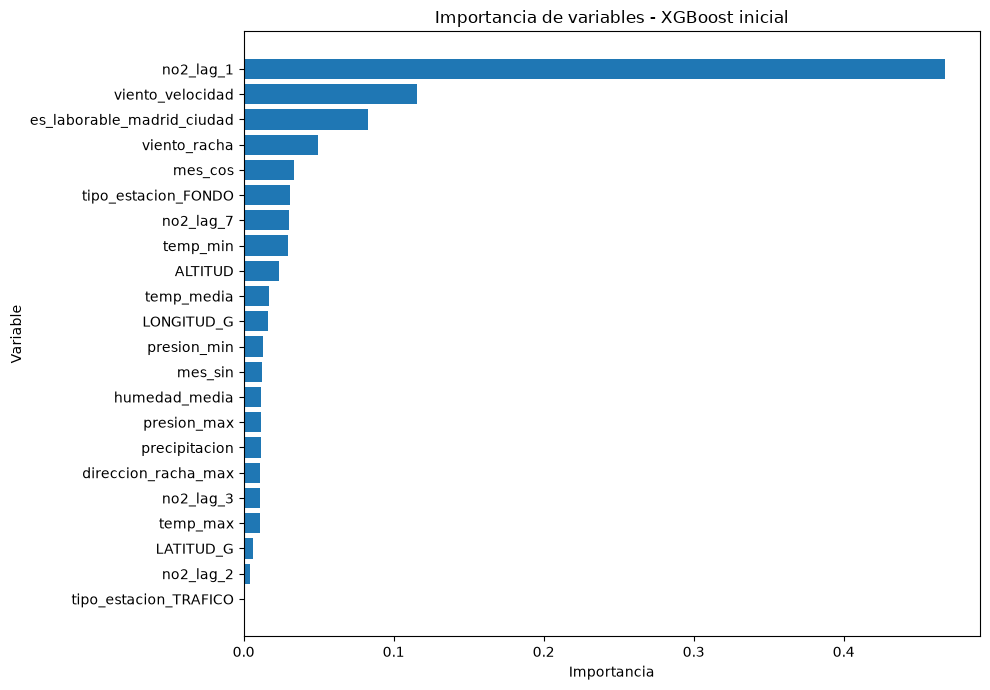

In [15]:
# ============================================================
# IMPORTANCIA DE VARIABLES - XGBOOST INICIAL
# ============================================================

import matplotlib.pyplot as plt

importancias = pd.DataFrame({
    "feature": FEATURES,
    "importancia": modelo_xgb.feature_importances_
}).sort_values(
    "importancia",
    ascending=False
)

display(importancias)

plt.figure(figsize=(10, 7))

plt.barh(
    importancias["feature"][::-1],
    importancias["importancia"][::-1]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables - XGBoost inicial")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# ERROR DE VALIDACIÓN POR ESTACIÓN
# ============================================================

evaluacion_val = df.loc[
    val_mask,
    ["fecha", "estacion", TARGET]
].copy()

evaluacion_val["prediccion"] = y_pred_val

evaluacion_val["error_absoluto"] = (
    evaluacion_val[TARGET]
    - evaluacion_val["prediccion"]
).abs()

error_estacion = (
    evaluacion_val
    .groupby("estacion")
    .agg(
        n=("error_absoluto", "size"),
        MAE=("error_absoluto", "mean")
    )
    .sort_values("MAE")
)

display(error_estacion)

,n,MAE
estacion,,
58,365,2.864763
24,365,4.103539
49,365,4.612501
18,365,4.900790
59,365,4.985368
60,365,5.018645
57,365,5.151002
47,365,5.279126
16,365,5.297808


## Optimización de hiperparámetros

Tras evaluar el modelo inicial, se realiza una optimización de hiperparámetros utilizando exclusivamente el periodo de entrenamiento 2020-2022.

Debido a la naturaleza temporal del problema, la validación cruzada se realiza mediante particiones temporales expansivas, evitando mezclas aleatorias entre pasado y futuro.

Además, dado que existen múltiples observaciones correspondientes a una misma fecha —una por estación—, los folds se construyen utilizando fechas completas. De este modo, todas las observaciones pertenecientes a un mismo día permanecen dentro del mismo conjunto.

El conjunto de validación de 2023 no interviene en la selección de hiperparámetros y se utiliza posteriormente como validación externa. El conjunto de test de 2024 permanece reservado para la evaluación final.

In [17]:
# ============================================================
# CONSTRUCCIÓN DE FOLDS TEMPORALES POR FECHA
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

fechas_train = (
    df_modelo
    .loc[train_mask, "fecha"]
    .reset_index(drop=True)
)

fechas_unicas = np.sort(
    fechas_train.unique()
)

print("Fechas únicas en train:", len(fechas_unicas))
print(
    "Periodo:",
    fechas_unicas[0],
    "→",
    fechas_unicas[-1]
)

Fechas únicas en train: 1089
Periodo: 2020-01-08T00:00:00.000000 → 2022-12-31T00:00:00.000000


In [18]:
# ============================================================
# VALIDACIÓN TEMPORAL EXPANSIVA
# ============================================================

tscv_fechas = TimeSeriesSplit(
    n_splits=4
)

cv_temporal = []

for fold, (train_dates_idx, val_dates_idx) in enumerate(
    tscv_fechas.split(fechas_unicas),
    start=1
):

    fechas_fold_train = fechas_unicas[
        train_dates_idx
    ]

    fechas_fold_val = fechas_unicas[
        val_dates_idx
    ]

    idx_train = np.where(
        fechas_train.isin(
            fechas_fold_train
        )
    )[0]

    idx_val = np.where(
        fechas_train.isin(
            fechas_fold_val
        )
    )[0]

    cv_temporal.append(
        (idx_train, idx_val)
    )

    print(f"\nFOLD {fold}")

    print(
        "Train:",
        fechas_fold_train[0],
        "→",
        fechas_fold_train[-1],
        f"({len(idx_train)} observaciones)"
    )

    print(
        "Validation:",
        fechas_fold_val[0],
        "→",
        fechas_fold_val[-1],
        f"({len(idx_val)} observaciones)"
    )


FOLD 1
Train: 2020-01-08T00:00:00.000000 → 2020-08-15T00:00:00.000000 (4862 observaciones)
Validation: 2020-08-16T00:00:00.000000 → 2021-03-20T00:00:00.000000 (4774 observaciones)

FOLD 2
Train: 2020-01-08T00:00:00.000000 → 2021-03-20T00:00:00.000000 (9636 observaciones)
Validation: 2021-03-21T00:00:00.000000 → 2021-10-23T00:00:00.000000 (4774 observaciones)

FOLD 3
Train: 2020-01-08T00:00:00.000000 → 2021-10-23T00:00:00.000000 (14410 observaciones)
Validation: 2021-10-24T00:00:00.000000 → 2022-05-28T00:00:00.000000 (4774 observaciones)

FOLD 4
Train: 2020-01-08T00:00:00.000000 → 2022-05-28T00:00:00.000000 (19184 observaciones)
Validation: 2022-05-29T00:00:00.000000 → 2022-12-31T00:00:00.000000 (4774 observaciones)


In [19]:
# ============================================================
# RANDOMIZED SEARCH
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "n_estimators": [300, 500, 700, 900, 1200],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.05, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0.5, 1, 2, 5]
}

modelo_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=cv_temporal,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
)

print("\nMejores hiperparámetros:")

for parametro, valor in (
    random_search.best_params_.items()
):
    print(f"- {parametro}: {valor}")

print(
    "\nMAE medio CV temporal:",
    -random_search.best_score_
)

Fitting 4 folds for each of 40 candidates, totalling 160 fits

Mejores hiperparámetros:
- subsample: 0.9
- reg_lambda: 2
- reg_alpha: 0
- n_estimators: 700
- min_child_weight: 3
- max_depth: 5
- learning_rate: 0.03
- gamma: 0.1
- colsample_bytree: 0.7

MAE medio CV temporal: 5.493488392966791


In [20]:
# ============================================================
# EVALUACIÓN DEL MODELO OPTIMIZADO - VALIDATION 2023
# ============================================================

modelo_optimizado = (
    random_search.best_estimator_
)

y_pred_val_opt = (
    modelo_optimizado
    .predict(X_val)
)

mae_val_opt = mean_absolute_error(
    y_val,
    y_pred_val_opt
)

rmse_val_opt = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_val_opt
    )
)

r2_val_opt = r2_score(
    y_val,
    y_pred_val_opt
)

print(
    "XGBOOST CON LAGS OPTIMIZADO - "
    "VALIDATION 2023"
)
print("-------------------------------------")
print(f"MAE:  {mae_val_opt:.3f}")
print(f"RMSE: {rmse_val_opt:.3f}")
print(f"R²:   {r2_val_opt:.3f}")

XGBOOST CON LAGS OPTIMIZADO - VALIDATION 2023
-------------------------------------
MAE:  5.300
RMSE: 6.910
R²:   0.803


In [21]:
# ============================================================
# COMPARACIÓN DE CONFIGURACIONES DE LAGS
# ============================================================

configuraciones_lags = {
    "lag_1": [
        "no2_lag_1"
    ],
    "lag_1 + lag_7": [
        "no2_lag_1",
        "no2_lag_7"
    ],
    "lag_1 + lag_2 + lag_3": [
        "no2_lag_1",
        "no2_lag_2",
        "no2_lag_3"
    ],
    "lag_1 + lag_2 + lag_3 + lag_7": [
        "no2_lag_1",
        "no2_lag_2",
        "no2_lag_3",
        "no2_lag_7"
    ]
}

features_base = (
    features_meteo
    + features_calendario
    + features_espaciales
    + columnas_tipo_estacion
)

resultados_lags = []

for nombre, lags in configuraciones_lags.items():

    features_config = (
        features_base + lags
    )

    modelo_config = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **random_search.best_params_
    )

    modelo_config.fit(
        df_modelo.loc[train_mask, features_config],
        y_train
    )

    pred_val = modelo_config.predict(
        df_modelo.loc[val_mask, features_config]
    )

    resultados_lags.append({
        "configuracion": nombre,
        "n_lags": len(lags),
        "MAE": mean_absolute_error(
            y_val,
            pred_val
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_val,
                pred_val
            )
        ),
        "R2": r2_score(
            y_val,
            pred_val
        )
    })

resultados_lags = (
    pd.DataFrame(resultados_lags)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    resultados_lags.round(4)
)

,configuracion,n_lags,MAE,RMSE,R2
0,lag_1 + lag_2 + lag_3,3,5.2960,6.9025,0.8032
1,lag_1 + lag_2 + lag_3 + lag_7,4,5.3001,6.9100,0.8028
2,lag_1 + lag_7,2,5.3048,6.8798,0.8045
3,lag_1,1,5.3173,6.9402,0.8011


### Selección de retardos temporales

Se compararon diferentes configuraciones de variables retardadas con el objetivo de determinar cuánta información histórica del NO₂ resulta necesaria para mantener la capacidad predictiva del modelo.

Los resultados obtenidos en validación muestran un comportamiento muy similar entre las diferentes configuraciones. La combinación `lag_1 + lag_2 + lag_3` obtiene el menor MAE (5.296 µg/m³), mientras que la combinación `lag_1 + lag_7` alcanza un MAE prácticamente equivalente (5.305 µg/m³) y presenta simultáneamente el menor RMSE (6.880 µg/m³) y el mayor R² (0.805).

La diferencia de MAE entre ambas configuraciones es inferior a 0.01 µg/m³, por lo que la incorporación de los retardos de dos y tres días no proporciona una mejora predictiva relevante.

Por este motivo se selecciona la configuración formada por `lag_1` y `lag_7`, que permite representar tanto la persistencia inmediata del contaminante como su comportamiento semanal utilizando un menor número de variables.

Esta elección proporciona un modelo más parsimonioso sin una pérdida apreciable de rendimiento.

In [22]:
features_lags = [
    "no2_lag_1",
    "no2_lag_7"
]

In [23]:
FEATURES = (
    features_meteo
    + features_calendario
    + features_espaciales
    + columnas_tipo_estacion
    + features_lags
)

X = df_modelo[FEATURES].copy()
y = df_modelo[TARGET].copy()

In [24]:
# ============================================================
# TUNING DEFINITIVO - MODELO CON LAG 1 + LAG 7
# ============================================================

modelo_base_final = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

random_search_final = RandomizedSearchCV(
    estimator=modelo_base_final,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=cv_temporal,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_final.fit(
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
)

print("\nMEJORES HIPERPARÁMETROS DEFINITIVOS")
print("-----------------------------------")

for parametro, valor in random_search_final.best_params_.items():
    print(f"{parametro}: {valor}")

print(
    "\nMAE medio CV temporal:",
    round(-random_search_final.best_score_, 4)
)

Fitting 4 folds for each of 40 candidates, totalling 160 fits

MEJORES HIPERPARÁMETROS DEFINITIVOS
-----------------------------------
subsample: 0.9
reg_lambda: 2
reg_alpha: 0
n_estimators: 700
min_child_weight: 3
max_depth: 5
learning_rate: 0.03
gamma: 0.1
colsample_bytree: 0.7

MAE medio CV temporal: 5.4935


In [25]:
# ============================================================
# VALIDACIÓN EXTERNA - 2023
# ============================================================

modelo_lags_final = random_search_final.best_estimator_

y_pred_val_lags = modelo_lags_final.predict(X_val)

mae_val_lags = mean_absolute_error(
    y_val,
    y_pred_val_lags
)

rmse_val_lags = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_val_lags
    )
)

r2_val_lags = r2_score(
    y_val,
    y_pred_val_lags
)

print("XGBOOST CON LAGS DEFINITIVO - VALIDATION 2023")
print("----------------------------------------------")
print(f"MAE:  {mae_val_lags:.3f}")
print(f"RMSE: {rmse_val_lags:.3f}")
print(f"R²:   {r2_val_lags:.3f}")

XGBOOST CON LAGS DEFINITIVO - VALIDATION 2023
----------------------------------------------
MAE:  5.300
RMSE: 6.910
R²:   0.803


In [26]:
# ============================================================
# COMPARACIÓN EN VALIDACIÓN 2023
# ============================================================

comparacion_validacion = pd.DataFrame({
    "modelo": [
        "Sin lags",
        "Con lag 1 + lag 7"
    ],
    "MAE": [
        6.250,
        mae_val_lags
    ],
    "RMSE": [
        8.175,
        rmse_val_lags
    ],
    "R2": [
        0.724,
        r2_val_lags
    ]
})

display(
    comparacion_validacion.round(3)
)

,modelo,MAE,RMSE,R2
0,Sin lags,6.25,8.175,0.724
1,Con lag 1 + lag 7,5.30,6.910,0.803


### Comparación en validación

La incorporación de información histórica del propio contaminante produce una mejora clara del rendimiento predictivo.

El modelo sin lags obtiene un MAE de 6.250 µg/m³ y un R² de 0.724, mientras que el modelo que incorpora las concentraciones de NO₂ del día anterior y de siete días antes reduce el MAE hasta 5.300 µg/m³ y aumenta el R² hasta 0.803.

Esto representa una reducción aproximada del 15 % tanto en MAE como en RMSE, mostrando que la información histórica reciente del contaminante aporta capacidad predictiva adicional respecto a la proporcionada exclusivamente por las variables meteorológicas, temporales y espaciales.

Estos resultados evidencian la existencia de una dependencia temporal relevante en las concentraciones de NO₂. No obstante, la comparación definitiva entre ambos enfoques se realizará sobre el conjunto de test de 2024, que no ha intervenido en ninguna etapa de selección u optimización del modelo.

In [27]:
# ============================================================
# REENTRENAMIENTO FINAL: 2020-2023
# ============================================================

train_final_mask = (
    df_modelo["fecha"] < "2024-01-01"
)

test_final_mask = (
    df_modelo["fecha"] >= "2024-01-01"
)

X_train_final = X.loc[train_final_mask].copy()
y_train_final = y.loc[train_final_mask].copy()

X_test_final = X.loc[test_final_mask].copy()
y_test_final = y.loc[test_final_mask].copy()

print("TRAIN FINAL")
print(
    df_modelo.loc[train_final_mask, "fecha"].min(),
    "→",
    df_modelo.loc[train_final_mask, "fecha"].max()
)
print("Observaciones:", len(X_train_final))

print("\nTEST FINAL")
print(
    df_modelo.loc[test_final_mask, "fecha"].min(),
    "→",
    df_modelo.loc[test_final_mask, "fecha"].max()
)
print("Observaciones:", len(X_test_final))

TRAIN FINAL
2020-01-08 00:00:00 → 2023-12-31 00:00:00
Observaciones: 31988

TEST FINAL
2024-01-01 00:00:00 → 2024-12-31 00:00:00
Observaciones: 8052


In [28]:
# ============================================================
# MODELO FINAL CON LAGS
# ============================================================

modelo_final_lags = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **random_search_final.best_params_
)

modelo_final_lags.fit(
    X_train_final,
    y_train_final
)

print("✓ Modelo final entrenado con datos 2020-2023.")

✓ Modelo final entrenado con datos 2020-2023.


In [29]:
# ============================================================
# EVALUACIÓN FINAL - TEST 2024
# ============================================================

y_pred_test_lags = modelo_final_lags.predict(
    X_test_final
)

mae_test_lags = mean_absolute_error(
    y_test_final,
    y_pred_test_lags
)

rmse_test_lags = np.sqrt(
    mean_squared_error(
        y_test_final,
        y_pred_test_lags
    )
)

r2_test_lags = r2_score(
    y_test_final,
    y_pred_test_lags
)

print("RESULTADOS FINALES CON LAGS - TEST 2024")
print("----------------------------------------")
print(f"MAE:  {mae_test_lags:.3f}")
print(f"RMSE: {rmse_test_lags:.3f}")
print(f"R²:   {r2_test_lags:.3f}")

RESULTADOS FINALES CON LAGS - TEST 2024
----------------------------------------
MAE:  4.693
RMSE: 6.042
R²:   0.807


## Evaluación final sobre el conjunto de test de 2024

El modelo definitivo con información histórica obtiene sobre el conjunto de test de 2024 un MAE de **4.693 µg/m³**, un RMSE de **6.042 µg/m³** y un R² de **0.807**.

Estos resultados representan una mejora considerable respecto al modelo equivalente sin información histórica, que obtuvo un MAE de 6.243 µg/m³, un RMSE de 7.953 µg/m³ y un R² de 0.666.

La incorporación de las concentraciones de NO₂ del día anterior y de siete días antes reduce aproximadamente un **24.8 % el MAE** y un **24.0 % el RMSE**, mientras que el coeficiente de determinación aumenta de 0.666 a 0.807.

La mejora observada en test es incluso superior a la registrada durante la validación de 2023, lo que evidencia la elevada utilidad de la información histórica del propio contaminante para generalizar a periodos posteriores.

Este resultado sugiere que la persistencia temporal del NO₂ contiene información relevante que no puede ser capturada completamente mediante las variables meteorológicas, temporales y espaciales utilizadas en el modelo sin lags.

## Importancia de las variables

Una vez seleccionado y evaluado el modelo definitivo, se analiza la importancia relativa de las variables utilizadas por XGBoost.

Esta medida permite identificar qué características son utilizadas con mayor intensidad por el modelo para realizar sus predicciones. En particular, resulta de interés analizar la relevancia adquirida por las variables históricas `no2_lag_1` y `no2_lag_7` respecto a las variables meteorológicas, temporales y espaciales.

La importancia interna proporcionada por XGBoost permite obtener una primera aproximación a la relevancia de las variables, aunque no informa sobre la dirección de su efecto sobre las predicciones. Posteriormente se utilizarán valores SHAP para realizar un análisis más completo e interpretable.

In [34]:
# ============================================================
# IMPORTANCIA DE VARIABLES - MODELO FINAL CON LAGS
# ============================================================

importancias = pd.DataFrame({
    "feature": X_train_final.columns,
    "importancia": modelo_final_lags.feature_importances_
})

importancias = (
    importancias
    .sort_values(
        "importancia",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importancias.round(4)
)

,feature,importancia
0,no2_lag_1,0.3493
1,viento_racha,0.1272
2,es_laborable_madrid_ciudad,0.0889
3,viento_velocidad,0.0728
4,mes_cos,0.0684
5,no2_lag_7,0.0567
6,LONGITUD_G,0.0273
7,ALTITUD,0.0265
8,tipo_estacion_TRAFICO,0.0245
9,temp_min,0.0238


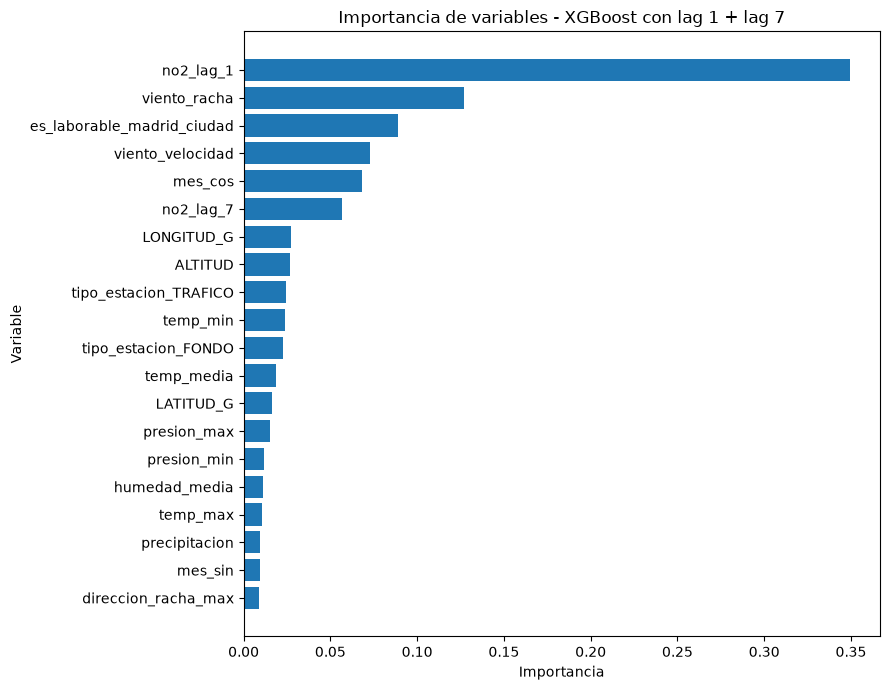

In [35]:
# ============================================================
# GRÁFICA DE IMPORTANCIA DE VARIABLES
# ============================================================

plt.figure(figsize=(9, 7))

plt.barh(
    importancias["feature"][::-1],
    importancias["importancia"][::-1]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title(
    "Importancia de variables - "
    "XGBoost con lag 1 + lag 7"
)

plt.tight_layout()
plt.show()

### Interpretación de la importancia de variables

La incorporación de información histórica modifica sustancialmente la jerarquía de las variables utilizadas por el modelo.

La concentración de NO₂ del día anterior (`no2_lag_1`) constituye claramente la variable con mayor importancia interna, situándose considerablemente por encima del resto de predictores. Este resultado evidencia una fuerte persistencia temporal en las concentraciones diarias de NO₂.

El retardo de siete días (`no2_lag_7`) presenta una importancia inferior, aunque mantiene una contribución relevante y complementaria a la información proporcionada por el día anterior.

Las variables meteorológicas relacionadas con el viento continúan ocupando posiciones destacadas. Asimismo, la condición de día laborable y la componente estacional mantienen una importancia considerable, indicando que meteorología y calendario siguen aportando información adicional incluso cuando se conoce el estado reciente del contaminante.

Respecto al modelo sin lags, la componente estacional y las características espaciales pierden protagonismo relativo. Esto sugiere que parte de la información estructural que anteriormente debía inferirse mediante la época del año y la localización puede ser capturada de forma más directa mediante las concentraciones recientes de NO₂.

En conjunto, los resultados muestran que la capacidad predictiva del modelo con lags se apoya principalmente en la persistencia temporal del contaminante, complementada por información meteorológica, temporal y espacial.

## Análisis de residuos del modelo con lags

Una vez evaluado el rendimiento global del modelo, se analizan los residuos sobre el conjunto de test de 2024.

El objetivo es comprobar si la incorporación de información histórica del NO₂, además de reducir el error predictivo, permite disminuir el sesgo de sobreestimación detectado en el modelo sin lags.

El residuo se define como:

\[
e_i = y_i - \hat{y}_i
\]

Por tanto, un residuo negativo indica sobreestimación y un residuo positivo indica infraestimación.

In [30]:
# ============================================================
# RESIDUOS - MODELO CON LAGS
# ============================================================

residuos_lags = (
    y_test_final.to_numpy()
    - y_pred_test_lags
)

print(
    f"Media real 2024:       "
    f"{y_test_final.mean():.3f}"
)

print(
    f"Media predicha 2024:   "
    f"{y_pred_test_lags.mean():.3f}"
)

print(
    f"Residuo medio:         "
    f"{residuos_lags.mean():.3f}"
)

print(
    f"Mediana residuos:      "
    f"{np.median(residuos_lags):.3f}"
)

print(
    f"Desv. estándar:        "
    f"{residuos_lags.std():.3f}"
)

Media real 2024:       22.969
Media predicha 2024:   24.879
Residuo medio:         -1.910
Mediana residuos:      -1.995
Desv. estándar:        5.732


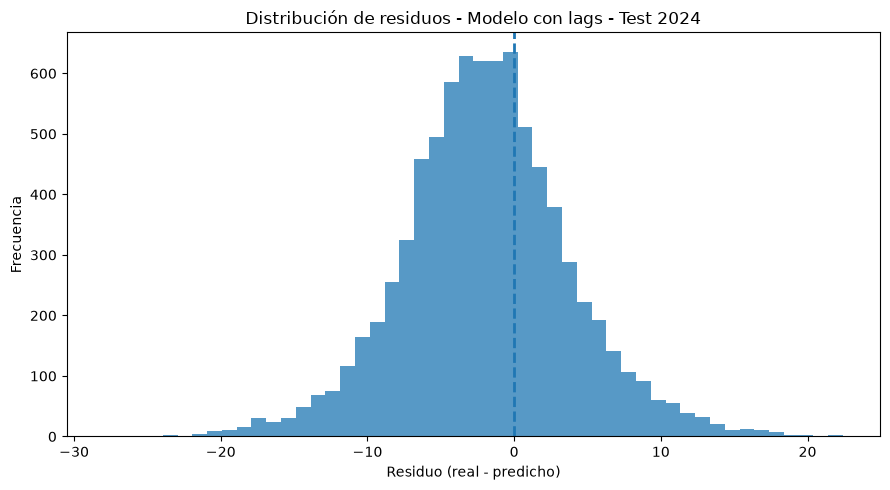

In [31]:
# ============================================================
# DISTRIBUCIÓN DE RESIDUOS
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    residuos_lags,
    bins=50,
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residuo (real - predicho)")
plt.ylabel("Frecuencia")
plt.title(
    "Distribución de residuos - "
    "Modelo con lags - Test 2024"
)

plt.tight_layout()
plt.show()

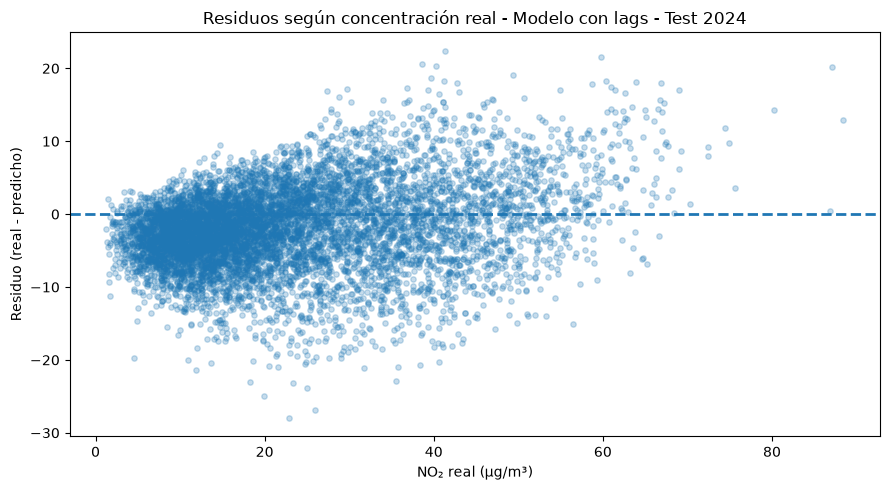

In [32]:
# ============================================================
# RESIDUOS SEGÚN CONCENTRACIÓN REAL
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    y_test_final,
    residuos_lags,
    alpha=0.25,
    s=15
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("NO₂ real (µg/m³)")
plt.ylabel("Residuo (real - predicho)")
plt.title(
    "Residuos según concentración real - "
    "Modelo con lags - Test 2024"
)

plt.tight_layout()
plt.show()

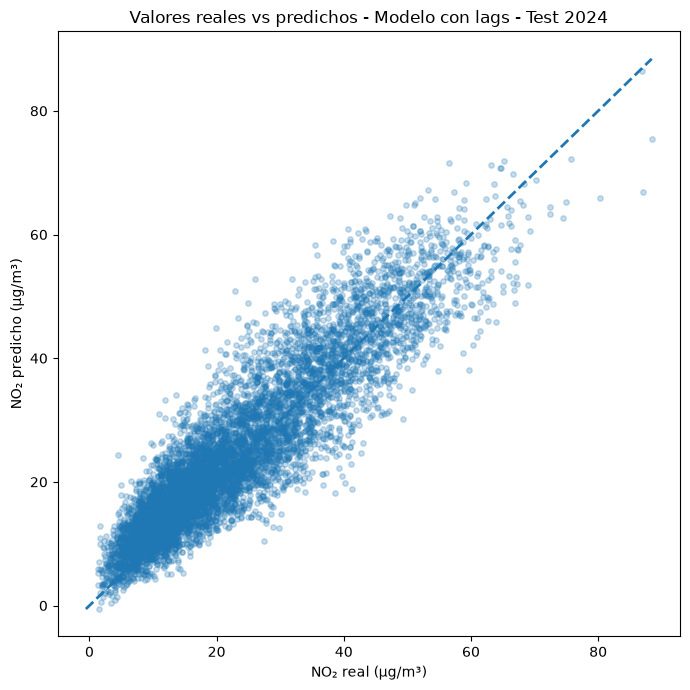

In [33]:
# ============================================================
# REAL VS PREDICHO
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_final,
    y_pred_test_lags,
    alpha=0.25,
    s=15
)

lim_min = min(
    y_test_final.min(),
    y_pred_test_lags.min()
)

lim_max = max(
    y_test_final.max(),
    y_pred_test_lags.max()
)

plt.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    linewidth=2
)

plt.xlabel("NO₂ real (µg/m³)")
plt.ylabel("NO₂ predicho (µg/m³)")
plt.title(
    "Valores reales vs predichos - "
    "Modelo con lags - Test 2024"
)

plt.tight_layout()
plt.show()

### Análisis de residuos y sesgo en 2024

El análisis de residuos muestra que la incorporación de información histórica del NO₂ no solo reduce el error predictivo global, sino que también disminuye considerablemente el sesgo observado en el modelo sin lags.

El modelo sin información histórica predecía una concentración media de 26.690 µg/m³ frente a una media real de 22.969 µg/m³, generando un residuo medio de -3.721 µg/m³. Con la incorporación de `lag_1` y `lag_7`, la media predicha disminuye hasta 24.879 µg/m³ y el residuo medio se reduce a -1.910 µg/m³.

Por tanto, la magnitud del sesgo medio de sobreestimación se reduce aproximadamente un 49 %. Asimismo, la desviación estándar de los residuos disminuye de 7.029 a 5.732 µg/m³, indicando una menor dispersión de los errores.

Estos resultados sugieren que la información histórica reciente permite al modelo adaptarse mejor al nivel de concentración observado durante 2024, periodo caracterizado por concentraciones medias inferiores a las registradas en 2023.

No obstante, el análisis de los residuos en función de la concentración real muestra que persiste cierta regresión hacia valores centrales. El modelo tiende a sobreestimar algunas concentraciones bajas y a infraestimar determinados valores elevados, aunque este comportamiento resulta menos acusado que en el modelo sin lags.

En conjunto, la incorporación de información histórica mejora tanto la precisión como la calibración temporal del modelo, aunque no elimina completamente la dificultad para reproducir concentraciones extremas.

## Análisis del rendimiento por estación

Tras analizar los residuos globales, se estudia el comportamiento del modelo de forma individual para cada estación de calidad del aire.

Este análisis permite comprobar si la mejora obtenida mediante la incorporación de información histórica es homogénea entre estaciones o si existen localizaciones donde el modelo presenta errores o sesgos sistemáticos.

Para cada estación se calculan:

- concentración media real de NO₂;
- concentración media predicha;
- MAE;
- residuo medio, definido como `real - predicho`;
- número de observaciones.

Un residuo medio negativo indica una tendencia a sobreestimar las concentraciones de NO₂, mientras que un residuo positivo indica una tendencia a infraestimarlas.

In [36]:
# ============================================================
# RESULTADOS POR ESTACIÓN - TEST 2024
# ============================================================

resultados_test = df_modelo.loc[
    test_final_mask,
    ["estacion"]
].copy()

resultados_test["NO2_real"] = (
    y_test_final.to_numpy()
)

resultados_test["NO2_predicho"] = (
    y_pred_test_lags
)

resultados_test["error_abs"] = np.abs(
    resultados_test["NO2_real"]
    - resultados_test["NO2_predicho"]
)

resultados_test["residuo"] = (
    resultados_test["NO2_real"]
    - resultados_test["NO2_predicho"]
)

# Añadimos nombre y tipo de estación
info_estaciones = estaciones_aire[
    [
        "ESTACION",
        "NOMBRE",
        "TIPO_ESTACION"
    ]
].copy()

info_estaciones = info_estaciones.rename(
    columns={"ESTACION": "estacion"}
)

resultados_test = resultados_test.merge(
    info_estaciones,
    on="estacion",
    how="left",
    validate="many_to_one"
)

resultados_estacion = (
    resultados_test
    .groupby(
        ["estacion", "NOMBRE", "TIPO_ESTACION"],
        as_index=False
    )
    .agg(
        NO2_real_medio=("NO2_real", "mean"),
        NO2_predicho_medio=("NO2_predicho", "mean"),
        MAE=("error_abs", "mean"),
        residuo_medio=("residuo", "mean"),
        n=("NO2_real", "size")
    )
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    resultados_estacion.round(3)
)

,estacion,NOMBRE,TIPO_ESTACION,NO2_real_medio,NO2_predicho_medio,MAE,residuo_medio,n
0,58,EL PARDO,FONDO,11.467,12.353000,2.720,-0.886,366
1,24,CASA DE CAMPO,FONDO,15.371,15.963000,3.567,-0.592,366
2,18,FAROLILLO,FONDO,25.780,26.122999,4.241,-0.343,366
3,57,SANCHINARRO,FONDO,20.256,22.131001,4.355,-1.875,366
4,60,TRES OLIVOS,FONDO,19.571,21.919001,4.371,-2.348,366
5,49,RETIRO,FONDO,14.943,18.139000,4.383,-3.196,366
6,35,PLAZA DEL CARMEN,FONDO,25.423,27.167000,4.440,-1.744,366
7,36,MORATALAZ,TRAFICO,25.694,27.112000,4.516,-1.417,366
8,59,JUAN CARLOS I,FONDO,20.178,20.962000,4.534,-0.784,366
9,16,ARTURO SORIA,FONDO,20.406,23.014000,4.557,-2.608,366


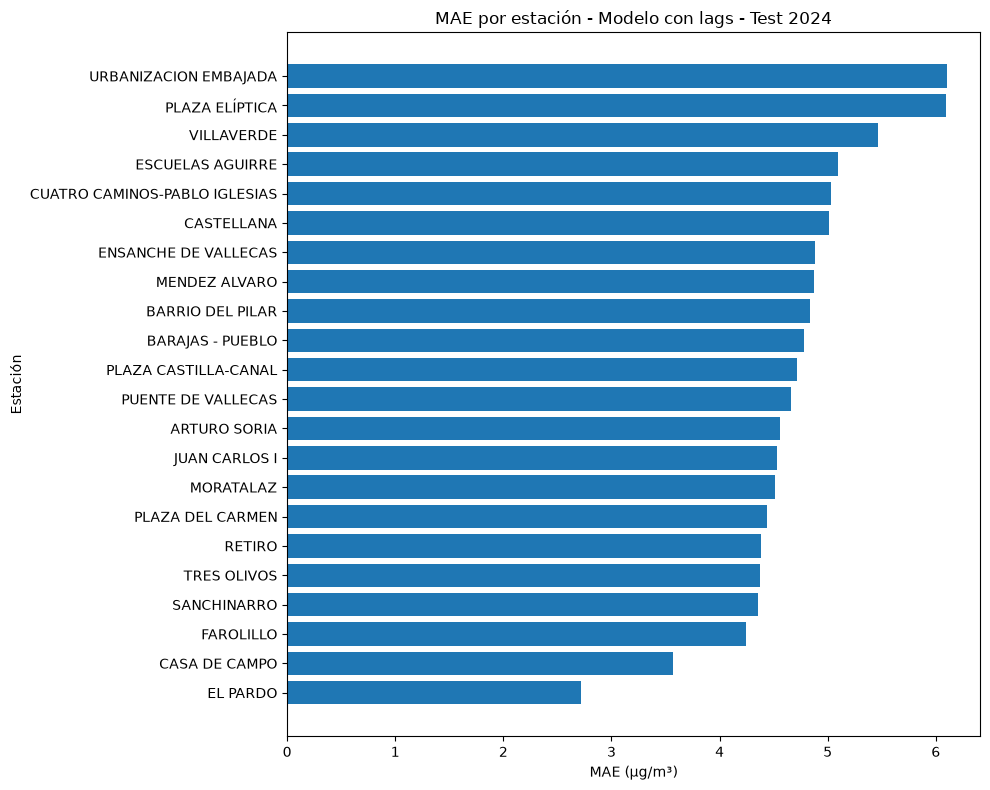

In [37]:
# ============================================================
# MAE POR ESTACIÓN
# ============================================================

orden_mae = (
    resultados_estacion
    .sort_values("MAE", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    orden_mae["NOMBRE"],
    orden_mae["MAE"]
)

plt.xlabel("MAE (µg/m³)")
plt.ylabel("Estación")
plt.title(
    "MAE por estación - "
    "Modelo con lags - Test 2024"
)

plt.tight_layout()
plt.show()

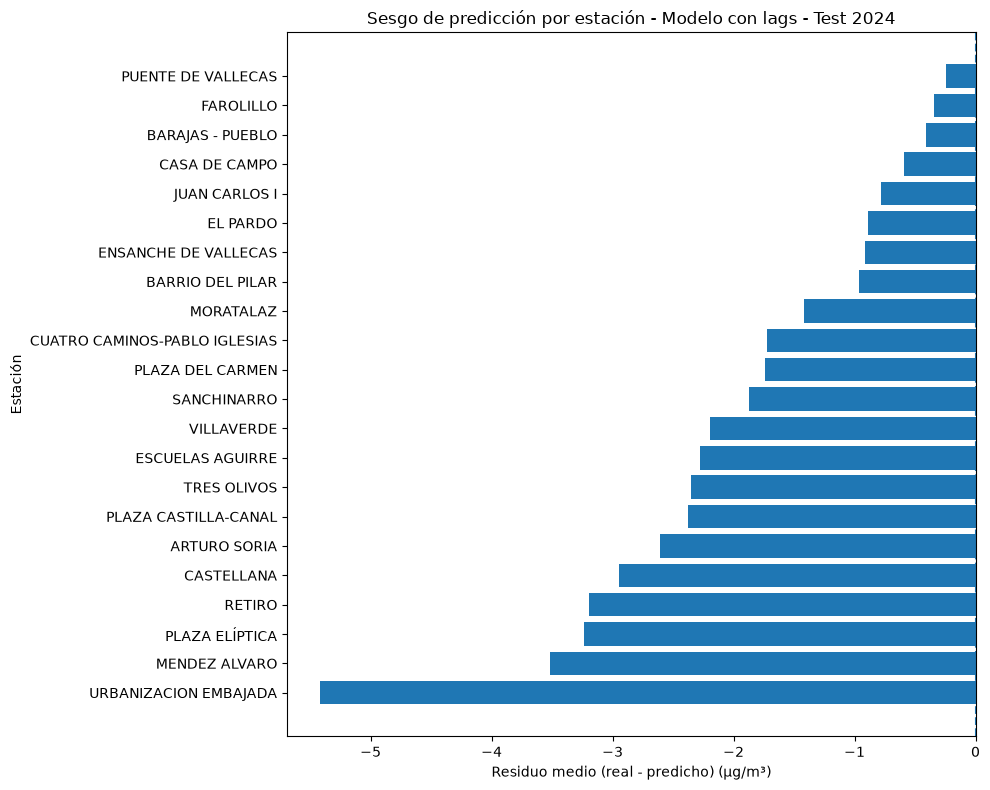

In [38]:
# ============================================================
# SESGO POR ESTACIÓN
# ============================================================

orden_sesgo = (
    resultados_estacion
    .sort_values("residuo_medio")
)

plt.figure(figsize=(10, 8))

plt.barh(
    orden_sesgo["NOMBRE"],
    orden_sesgo["residuo_medio"]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel(
    "Residuo medio (real - predicho) (µg/m³)"
)
plt.ylabel("Estación")
plt.title(
    "Sesgo de predicción por estación - "
    "Modelo con lags - Test 2024"
)

plt.tight_layout()
plt.show()

### Rendimiento por estación

El análisis desagregado por estación confirma que la mejora obtenida mediante la incorporación de información histórica no se concentra únicamente en determinadas localizaciones, sino que se observa de forma generalizada.

Los errores absolutos por estación se reducen considerablemente respecto al modelo sin lags. Destacan especialmente estaciones que anteriormente presentaban errores elevados, como Urbanización Embajada, Plaza Elíptica, Méndez Álvaro o Retiro.

Urbanización Embajada continúa siendo la estación con mayor dificultad predictiva, aunque su MAE disminuye de 11.147 a 6.104 µg/m³. De forma similar, Plaza Elíptica reduce su MAE de 9.156 a 6.091 µg/m³ y Méndez Álvaro de 7.562 a 4.872 µg/m³.

En diversas estaciones, además, la concentración media predicha se aproxima notablemente a la observada. Por ejemplo, Puente de Vallecas presenta un residuo medio de únicamente -0.245 µg/m³ y Farolillo de -0.343 µg/m³.

No obstante, todas las estaciones mantienen residuos medios negativos, indicando que persiste una tendencia sistemática a sobreestimar las concentraciones medias de NO₂ durante 2024. Esta sobreestimación es, sin embargo, considerablemente inferior a la observada en el modelo sin información histórica.

Por tanto, los resultados muestran que los lags permiten adaptar mejor las predicciones al comportamiento reciente del contaminante en las diferentes estaciones, aunque no eliminan completamente el sesgo asociado al cambio temporal observado en 2024.

## Interpretabilidad del modelo mediante SHAP

Para analizar cómo utiliza el modelo las diferentes variables predictoras se emplean valores SHAP (*SHapley Additive exPlanations*).

A diferencia de la importancia interna proporcionada por XGBoost, los valores SHAP permiten analizar no solo la relevancia global de cada variable, sino también la dirección y magnitud de su contribución a las predicciones.

Este análisis resulta especialmente relevante en el modelo con información histórica, ya que permite estudiar cómo las concentraciones de NO₂ del día anterior (`no2_lag_1`) y de siete días antes (`no2_lag_7`) modifican las predicciones respecto a las variables meteorológicas, temporales y espaciales.

In [40]:
# ============================================================
# SHAP - IMPORTACIÓN
# ============================================================

import shap

print("SHAP cargado correctamente.")
print("Versión:", shap.__version__)

SHAP cargado correctamente.
Versión: 0.52.0


In [41]:
# ============================================================
# CÁLCULO DE VALORES SHAP - TEST 2024
# ============================================================

# Muestra reproducible del conjunto de test
n_shap = min(3000, len(X_test_final))

X_shap = X_test_final.sample(
    n=n_shap,
    random_state=42
)

# Explicador para el modelo XGBoost definitivo
explainer = shap.TreeExplainer(
    modelo_final_lags
)

shap_values = explainer(
    X_shap
)

print("Observaciones analizadas:", len(X_shap))
print("Número de variables:", X_shap.shape[1])

Observaciones analizadas: 3000
Número de variables: 20


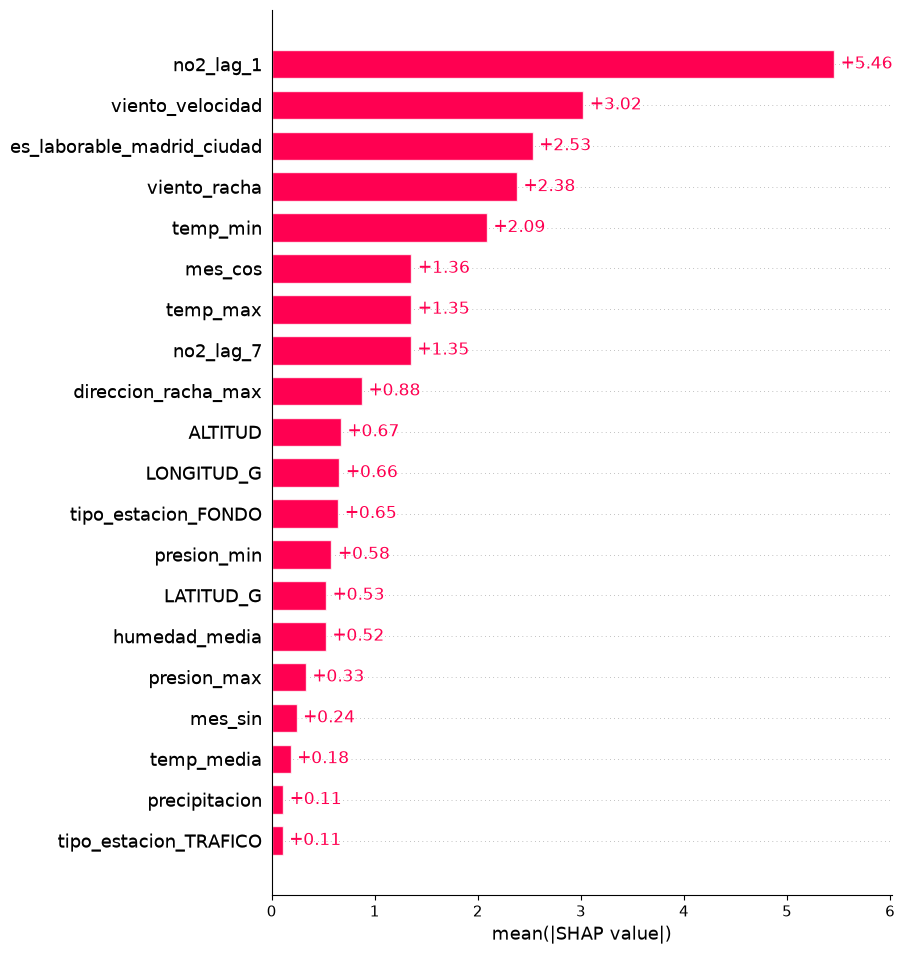

In [42]:
# ============================================================
# IMPORTANCIA GLOBAL SHAP
# ============================================================

shap.plots.bar(
    shap_values,
    max_display=len(FEATURES)
)

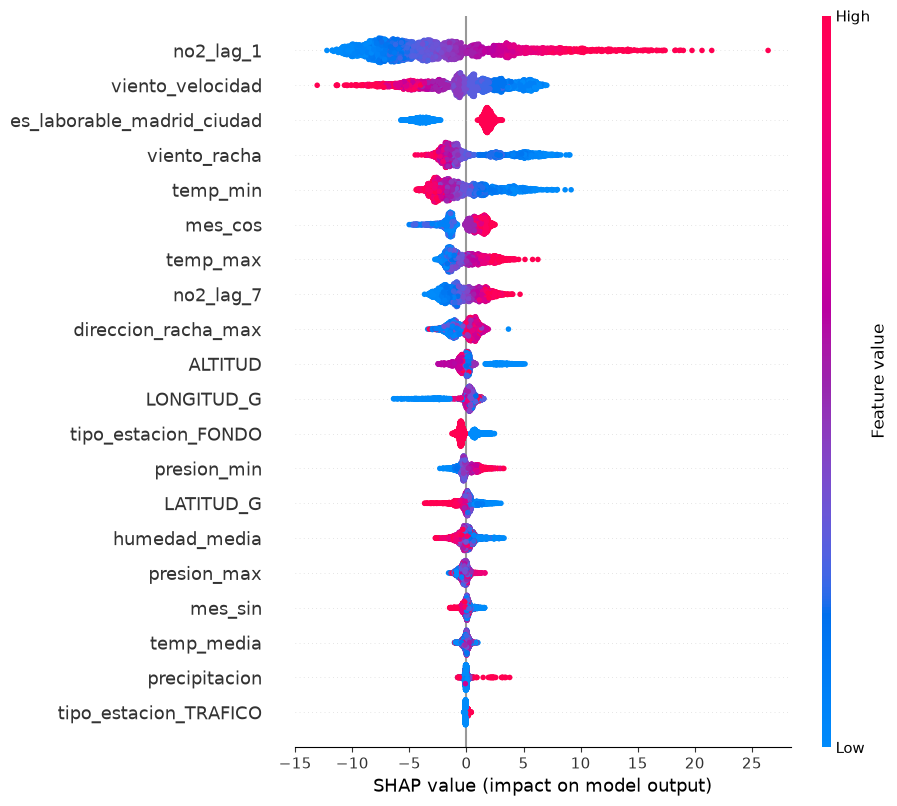

In [43]:
# ============================================================
# SHAP BEESWARM
# ============================================================

shap.plots.beeswarm(
    shap_values,
    max_display=len(FEATURES)
)

### Interpretación global mediante SHAP

El análisis SHAP confirma que la incorporación de información histórica modifica sustancialmente el funcionamiento del modelo.

La concentración de NO₂ del día anterior (`no2_lag_1`) constituye la variable con mayor impacto global, con un valor medio absoluto SHAP de 5.46 µg/m³. Los valores elevados del retardo generan contribuciones positivas, mientras que valores bajos producen contribuciones negativas. Este comportamiento evidencia una fuerte persistencia temporal en las concentraciones de NO₂.

El retardo de siete días (`no2_lag_7`) presenta el mismo patrón, aunque con un impacto considerablemente inferior, indicando que la información semanal complementa a la persistencia inmediata pero tiene una capacidad predictiva menor.

Las variables relacionadas con el viento continúan mostrando una influencia elevada. Velocidades y rachas altas presentan generalmente contribuciones negativas, mientras que condiciones de menor ventilación incrementan las predicciones. Asimismo, los días laborables mantienen contribuciones predominantemente positivas.

Una diferencia especialmente relevante respecto al modelo sin lags aparece en la componente estacional. `mes_cos`, que constituía la variable con mayor impacto SHAP en el modelo sin información histórica, reduce considerablemente su importancia tras incorporar los retardos de NO₂. Esto sugiere que parte de la información necesaria para situar temporalmente el nivel esperado del contaminante queda representada de forma más directa mediante sus concentraciones recientes.

Las características espaciales y el tipo de estación mantienen capacidad explicativa, aunque su impacto relativo disminuye respecto al modelo sin lags.

En conjunto, el modelo con información histórica se apoya principalmente en la persistencia temporal del NO₂, complementándola con información meteorológica, de calendario y espacial. Esta combinación permite explicar la mejora de rendimiento observada respecto al modelo sin lags.

### Efecto de la estacionalidad mensual

Aunque la importancia de la componente estacional disminuye tras incorporar información histórica del NO₂, `mes_cos` continúa presentando una contribución relevante.

Para facilitar su interpretación, se analiza la contribución SHAP media de la componente estacional para cada mes del año.

Este análisis permite estudiar si el patrón estacional aprendido por el modelo se mantiene tras incorporar las concentraciones recientes del contaminante y comparar su magnitud con la observada en el modelo sin lags.

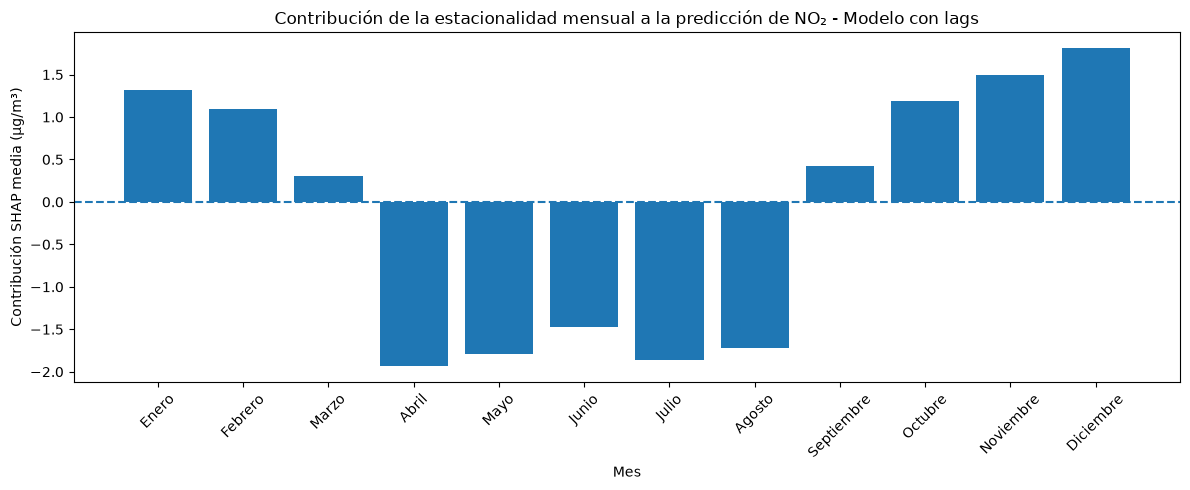

In [44]:
# ============================================================
# CONTRIBUCIÓN SHAP DE LA ESTACIONALIDAD POR MES
# ============================================================

# Posición de mes_cos dentro de las features
idx_mes_cos = X_shap.columns.get_loc("mes_cos")

# SHAP de mes_cos
shap_mes_cos = shap_values.values[:, idx_mes_cos]

# Recuperamos el mes de cada observación utilizada en SHAP
mes_shap = df_modelo.loc[
    X_shap.index,
    "fecha"
].dt.month.to_numpy()

# DataFrame auxiliar
df_shap_mes = pd.DataFrame({
    "mes": mes_shap,
    "shap_mes_cos": shap_mes_cos
})

# Contribución SHAP media por mes
shap_mensual = (
    df_shap_mes
    .groupby("mes")["shap_mes_cos"]
    .mean()
    .reindex(range(1, 13))
)

nombres_meses = [
    "Enero", "Febrero", "Marzo",
    "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre",
    "Octubre", "Noviembre", "Diciembre"
]

plt.figure(figsize=(12, 5))

plt.bar(
    nombres_meses,
    shap_mensual.values
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.ylabel(
    "Contribución SHAP media (µg/m³)"
)
plt.xlabel("Mes")

plt.title(
    "Contribución de la estacionalidad mensual "
    "a la predicción de NO₂ - Modelo con lags"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretación de la estacionalidad mensual

El patrón estacional aprendido por el modelo se mantiene tras incorporar las variables históricas de NO₂. Los meses de otoño e invierno presentan contribuciones SHAP positivas, mientras que durante primavera y verano predominan contribuciones negativas.

Sin embargo, la magnitud de este efecto disminuye considerablemente respecto al modelo sin lags. Mientras que en dicho modelo la componente estacional podía modificar la predicción en aproximadamente ±4–6 µg/m³ según el mes, en el modelo con información histórica las contribuciones mensuales se sitúan generalmente alrededor de ±1–2 µg/m³.

Esta reducción es coherente con la disminución de la importancia global de `mes_cos` observada mediante SHAP. La estacionalidad continúa aportando información relevante, pero parte de la señal temporal queda ahora representada de forma más directa mediante las concentraciones recientes de NO₂ (`no2_lag_1` y `no2_lag_7`).

Por tanto, la incorporación de lags no elimina el patrón estacional aprendido por el modelo, sino que reduce su dependencia explícita de la época del año al disponer de información reciente sobre el estado del contaminante.